# Assignment 2 Anomaly Detection in Time Series Data

## 1. Frame the Problem

### **1.1 Objective**
Detect anomalies in water pump sensor data to prevent failures.

### **1.2 Use Case**
- Monitor real-time sensor data.  
- Detect and alert on anomalies.  
- Reduce downtime and maintenance costs.  

### **1.3 Existing Solutions**
  

### **1.4 Problem Framing**
- **Unsupervised learning** (no labels).  
- Models: **Autoencoder, K-Means, Isolation Forest**.  

### **1.5 Evaluation**
We use the following metrics to assess anomaly detection performance:

- **Precision**: Measures how many of the detected anomalies are actually correct.  
  $$ \text{Precision} = \frac{TP}{TP + FP} $$

- **Recall**: Measures how many actual anomalies were successfully detected.  
  $$ \text{Recall} = \frac{TP}{TP + FN} $$

- **F1-score**: Harmonic mean of precision and recall, balancing both.  
  $$ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

Where:  
- **TP** = True Positives (correctly detected anomalies)  
- **FP** = False Positives (incorrectly flagged as anomalies)  
- **FN** = False Negatives (missed anomalies)  

And also **t-SNE visualization** for clustering models.  

### **1.6 Assumptions**
- Sensor data is reliable.  
- Anomalies are rare but significant.   


## 2 Get the Data

### **2.1 About the Dataset**
This dataset consists of **three main groups of data**:
- **Timestamp data**: Time-based records of machine operation.
- **Sensor data (52 series)**: Raw sensor values tracking machine performance.
- **Machine status**: The target variable `machine_status` indicating machine condition: `NORMAL`, `BROKEN` and `RECOVERING`.

In [11]:
import pandas as pd

# Load dataset
file_path = "dataset/sensor.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()


,NUM,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


### **2.3 Data Exploration**
We need to understand the structure of the dataset before proceeding with preprocessing.  
Key aspects to check:
- Number of features (timestamps + 52 sensors + machine status).
- Data types and missing values.
- Unique values in the **machine_status** column.


In [12]:

# **Check dataset structure**
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   NUM             220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

In [13]:
# Check unique labels in machine_status
df['machine_status'].unique()


array(['NORMAL', 'BROKEN', 'RECOVERING'], dtype=object)

In [14]:
# Summary statistics
df.describe()

,NUM,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,220320.000000,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,...,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,143303.000000,204937.000000
mean,110159.500000,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,...,35.453455,43.879591,42.656877,43.094984,48.018585,44.340903,150.889044,57.119968,183.049260,202.699667
std,63601.049991,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,...,10.259521,11.044404,11.576355,12.837520,15.641284,10.442437,82.244957,19.143598,65.258650,109.588607
min,0.000000,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,...,22.135416,24.479166,25.752316,26.331018,26.331018,27.199070,26.331018,26.620370,27.488426,27.777779
25%,55079.750000,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,...,32.812500,39.583330,36.747684,36.747684,40.509258,39.062500,83.912030,47.743060,167.534700,179.108800
50%,110159.500000,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,...,35.156250,42.968750,40.509260,40.219910,44.849540,42.534720,138.020800,52.662040,193.865700,197.338000
75%,165239.250000,2.499826,49.479160,52.777770,45.312500,637.615723,80.912150,14.539930,16.427950,15.697340,...,36.979164,46.614580,45.138890,44.849540,51.215280,46.585650,208.333300,60.763890,219.907400,216.724500
max,220319.000000,2.549016,56.727430,56.032990,48.220490,800.000000,99.999880,22.251160,23.596640,24.348960,...,374.218800,408.593700,1000.000000,320.312500,370.370400,303.530100,561.632000,464.409700,1000.000000,1000.000000


### **2.4 Storage**
- Check dataset size and storage needs.

In [15]:
# **Check dataset size in MB**
dataset_size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Dataset size: {dataset_size_mb:.2f} MB")

Dataset size: 114.99 MB


### **2.5 Prepare Data for Training**


In [16]:
# **Convert timestamp column to datetime**
df['timestamp'] = pd.to_datetime(df['timestamp'])

# **Check new data types**
df.dtypes

NUM                        int64
timestamp         datetime64[ns]
sensor_00                float64
sensor_01                float64
sensor_02                float64
sensor_03                float64
sensor_04                float64
sensor_05                float64
sensor_06                float64
sensor_07                float64
sensor_08                float64
sensor_09                float64
sensor_10                float64
sensor_11                float64
sensor_12                float64
sensor_13                float64
sensor_14                float64
sensor_15                float64
sensor_16                float64
sensor_17                float64
sensor_18                float64
sensor_19                float64
sensor_20                float64
sensor_21                float64
sensor_22                float64
sensor_23                float64
sensor_24                float64
sensor_25                float64
sensor_26                float64
sensor_27                float64
sensor_28 

### **2.6 Create Train/Test Split**
To evaluate model performance, we need a separate test set.  
We use an **80/20 split**, ensuring that the test set is never used in training.


In [17]:
from sklearn.model_selection import train_test_split

# **Split data into training and test set**
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# **Save test set for final evaluation**
test_set.to_csv("test_data.csv", index=False)


## 3. Explore the Data

### **3.1 Create a Copy for Exploration**
We work directly with the dataset but can sample if needed for performance reasons and check distribution of classes. 

In [18]:
# Take a sample if dataset is too large
df_sample = df

# Check class distribution
print(df['machine_status'].value_counts())

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


### **3.2 Study Dataset Characteristics**
We analyze each attribute, its type, missing values, and potential issues.


In [19]:
# **Check missing values percentage**
missing_values = df.isnull().sum() / len(df) * 100
missing_values = missing_values[missing_values > 0]  # Show only columns with missing values
missing_values


sensor_00      4.633261
sensor_01      0.167484
sensor_02      0.008624
sensor_03      0.008624
sensor_04      0.008624
sensor_05      0.008624
sensor_06      2.177741
sensor_07      2.474129
sensor_08      2.317992
sensor_09      2.085603
sensor_10      0.008624
sensor_11      0.008624
sensor_12      0.008624
sensor_13      0.008624
sensor_14      0.009532
sensor_15    100.000000
sensor_16      0.014070
sensor_17      0.020879
sensor_18      0.020879
sensor_19      0.007262
sensor_20      0.007262
sensor_21      0.007262
sensor_22      0.018609
sensor_23      0.007262
sensor_24      0.007262
sensor_25      0.016340
sensor_26      0.009078
sensor_27      0.007262
sensor_28      0.007262
sensor_29      0.032680
sensor_30      0.118464
sensor_31      0.007262
sensor_32      0.030864
sensor_33      0.007262
sensor_34      0.007262
sensor_35      0.007262
sensor_36      0.007262
sensor_37      0.007262
sensor_38      0.012255
sensor_39      0.012255
sensor_40      0.012255
sensor_41      0

### **3.3 Visualize Missing Data**
A heatmap provides a visual representation of missing values across the dataset.


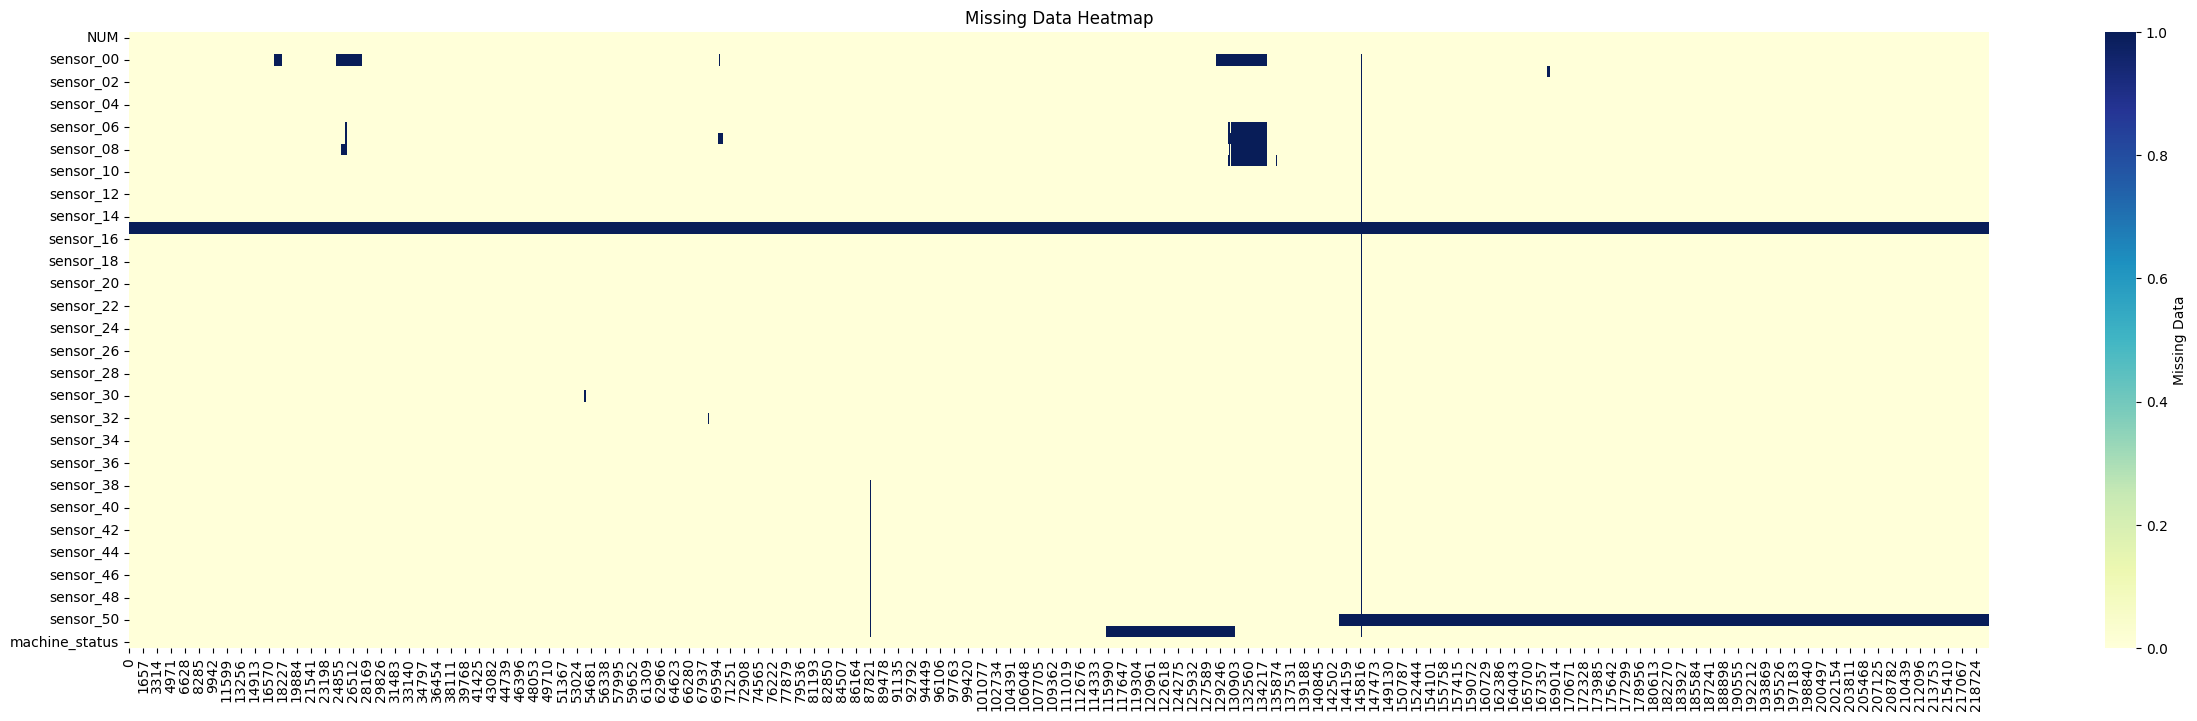

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Missing Data with a Heatmap
plt.figure(figsize=(30, 8))
sns.heatmap(df.isna().transpose(), cmap="YlGnBu", cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data Heatmap')
plt.show()



### **3.4 Sensor Data Distributions**
Understanding distributions helps detect outliers and assess normality.


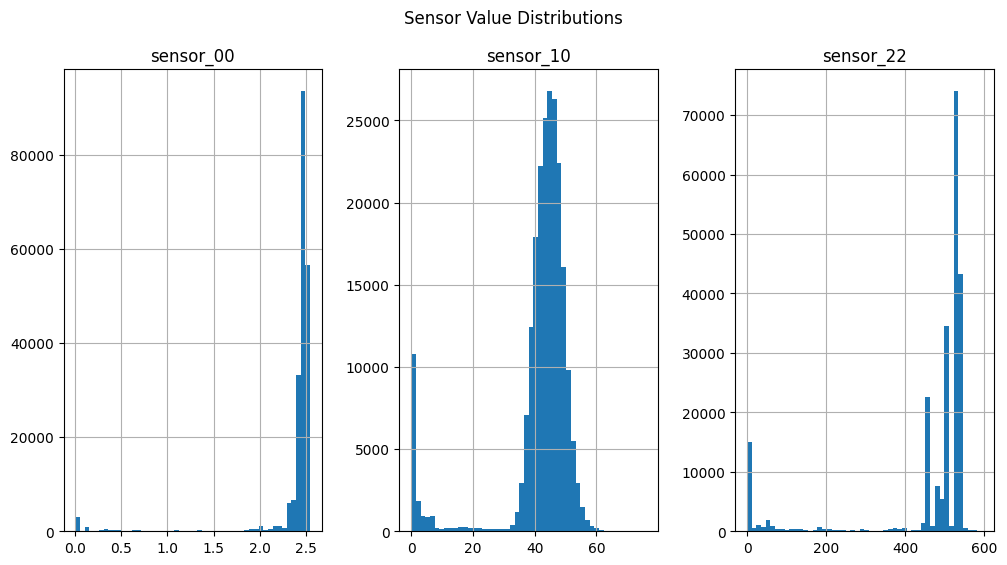

In [21]:
# **Plot histograms of selected sensors**
sensor_columns = ['sensor_00', 'sensor_10', 'sensor_22']

df[sensor_columns].hist(figsize=(12, 6), bins=50, layout=(1, 3))
plt.suptitle("Sensor Value Distributions")
plt.show()


### **3.5 Time-Series Trends**
A time-series plot can reveal sudden spikes or shifts that indicate anomalies.


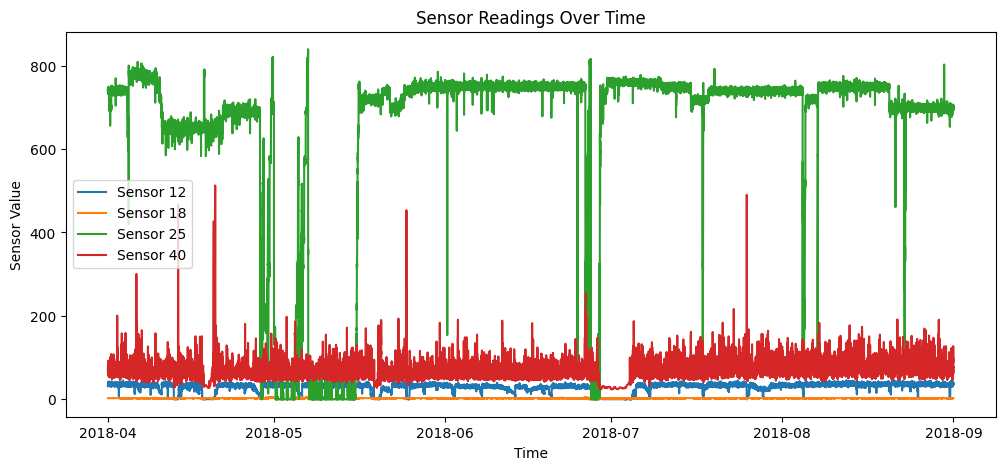

In [22]:
# **Plot time-series trends for selected sensors**
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['sensor_12'], label="Sensor 12")
plt.plot(df['timestamp'], df['sensor_18'], label="Sensor 18")
plt.plot(df['timestamp'], df['sensor_25'], label="Sensor 25")
plt.plot(df['timestamp'], df['sensor_40'], label="Sensor 40")

plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.legend()
plt.title("Sensor Readings Over Time")
plt.show()


### **3.8 Correlation Between Sensors**
A heatmap helps identify highly correlated sensors, which can aid in feature selection.


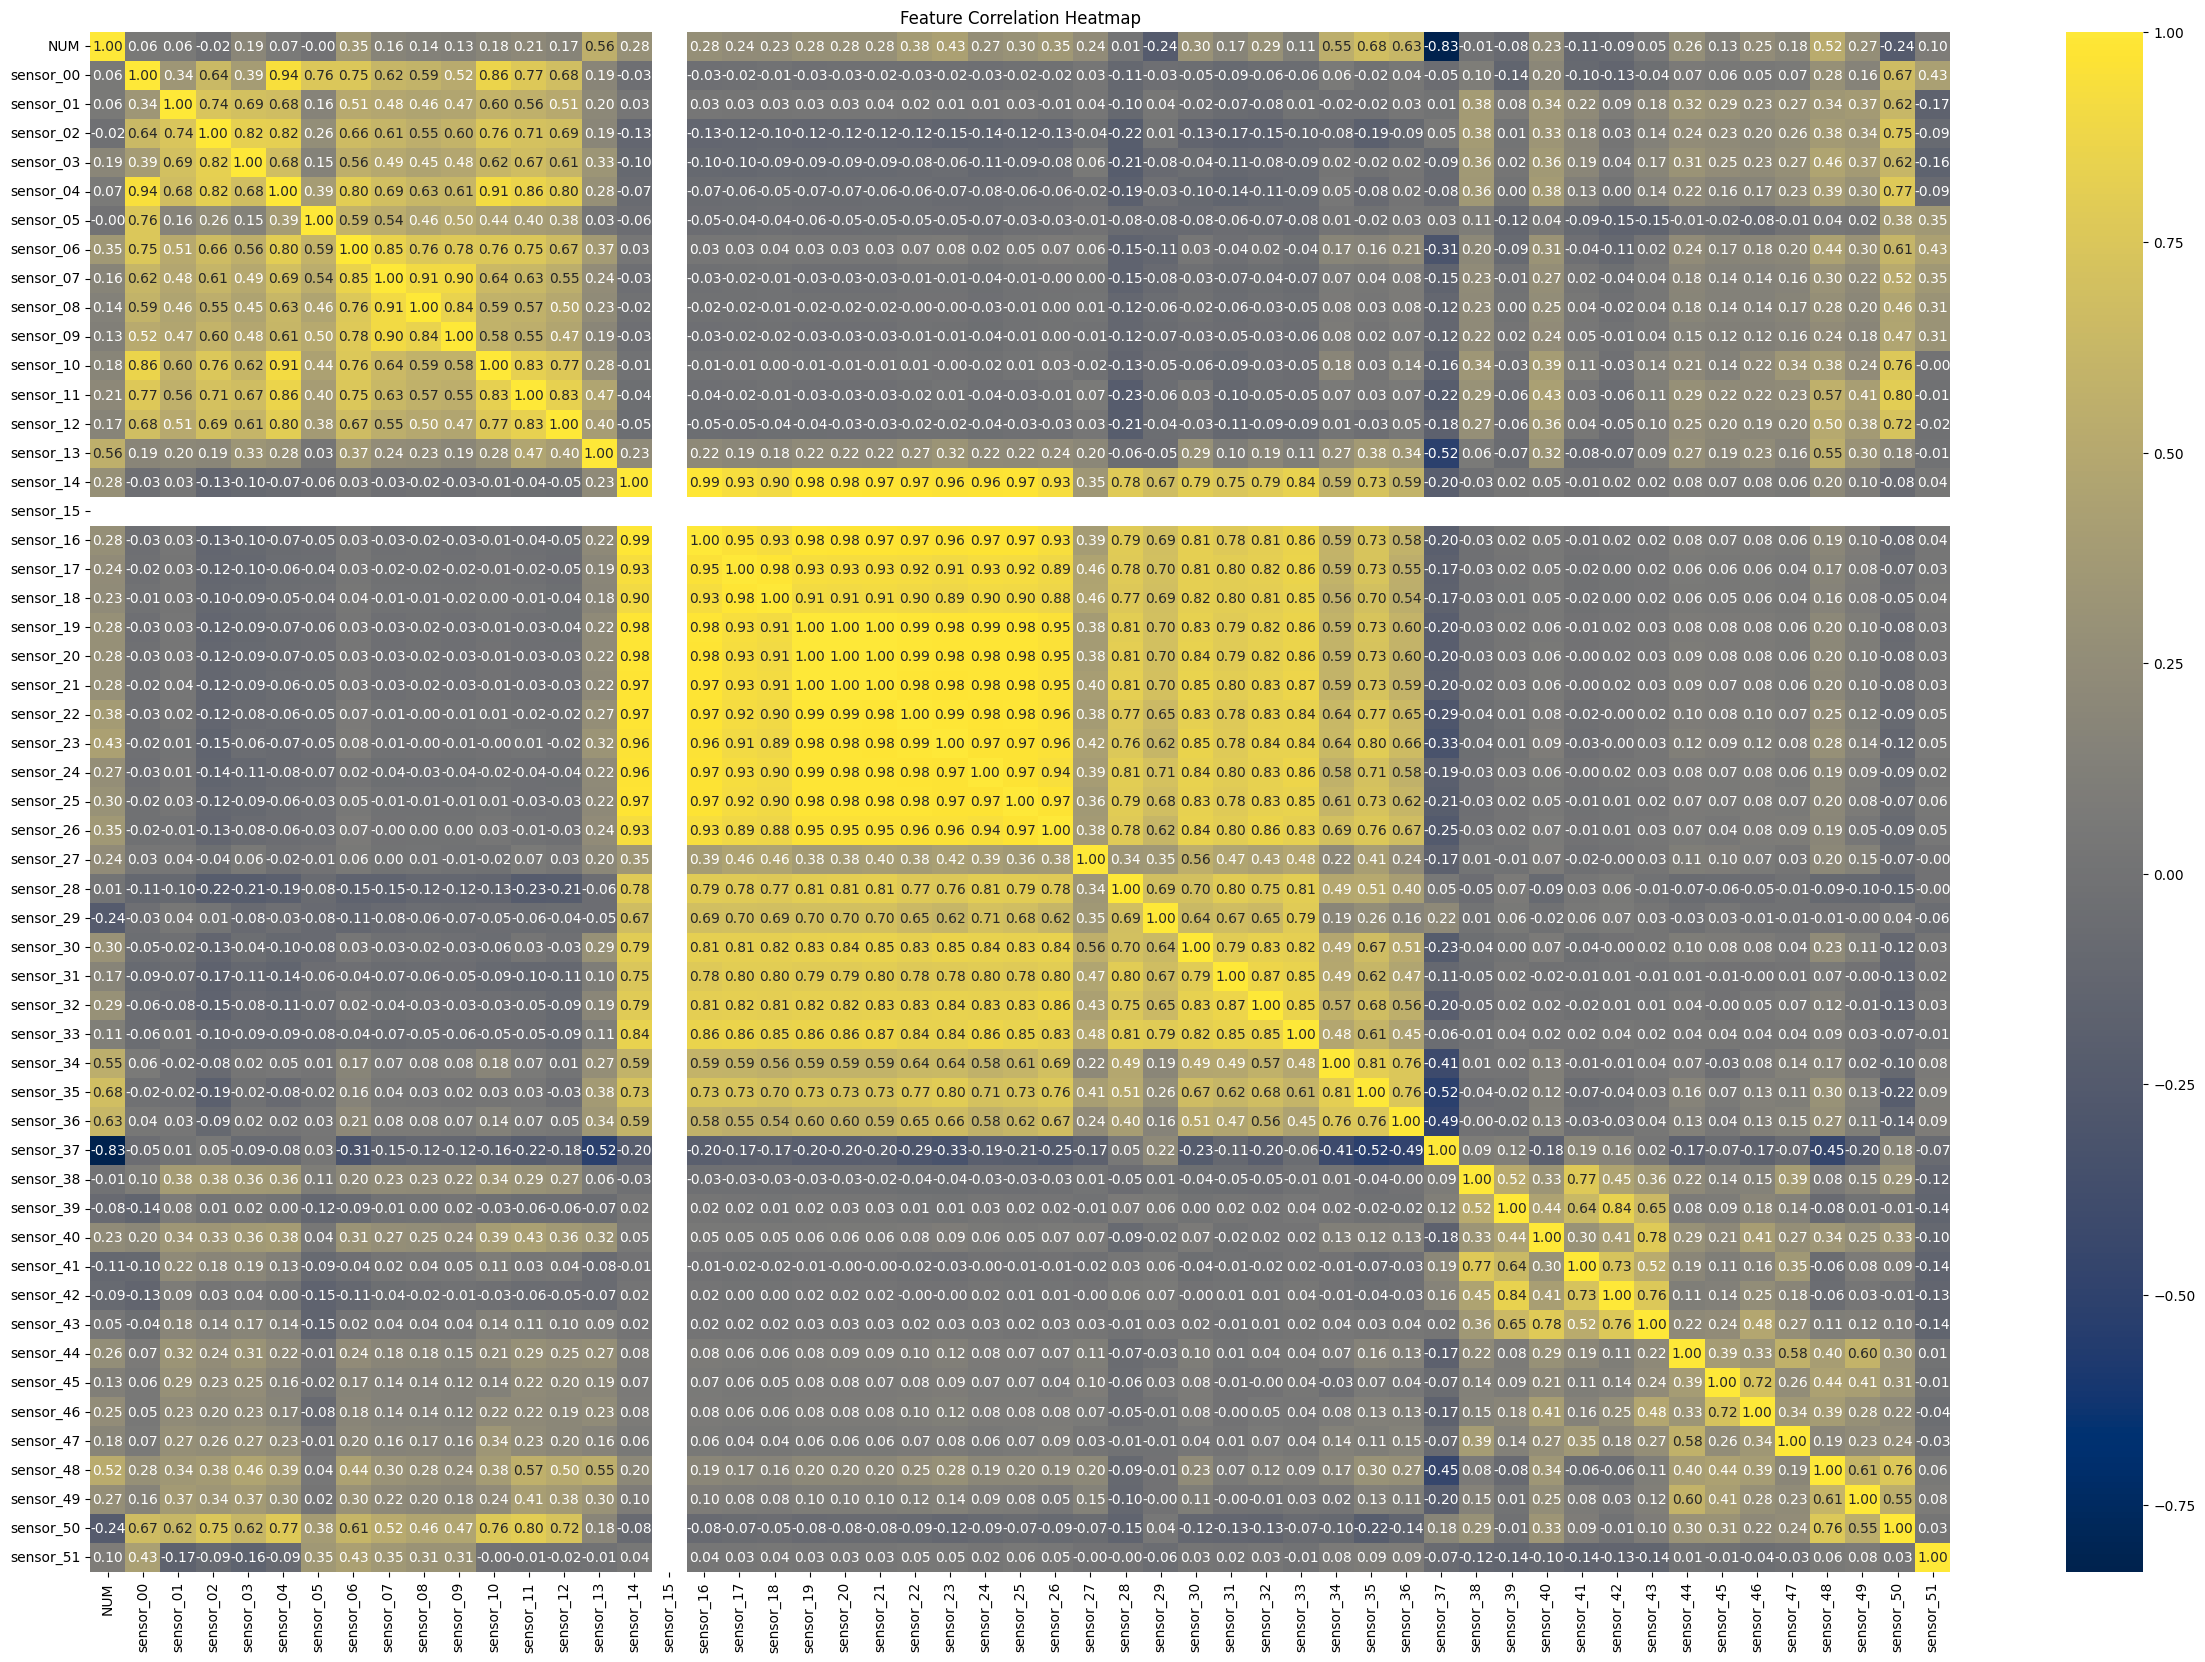

In [23]:
# Drop non-numeric columns
df_numeric = df.select_dtypes(include=['number'])

# **Compute correlation matrix**
corr_matrix = df_numeric.corr()

# Plot correlation heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix,  annot=True, cmap='cividis', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


### **3.6 Findings**
- **Missing data** exists in many sensors.
- **Sensor data distributions vary, some may need scaling.**
- Some highly **correlated** sensors.


## 4. Prepare the Data

### **4.1 Handling Missing Data**
Some sensors have a significant amount of missing values. We remove the ones that are completely empty or have excessive missing data.


In [24]:
# Drop columns with excessive missing values
df = df.drop(['sensor_15', 'sensor_00', 'sensor_50', 'sensor_51', 'NUM', 'timestamp'], axis=1)

# Confirm that the columns are removed
print("Remaining columns after dropping:", df.columns)


Remaining columns after dropping: Index(['sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05',
       'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26',
       'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31',
       'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36',
       'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41',
       'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46',
       'sensor_47', 'sensor_48', 'sensor_49', 'machine_status'],
      dtype='object')


### **4.2 Removing Redundant Sensors**
To reduce redundancy:
- We **keep one sensor** from each highly correlated pair (correlation > 0.98).
- The sensor to keep is selected arbitrarily (but we can refine this later if needed).


In [26]:
# Find and remove redundant sensors
corr_matrix_abs = corr_matrix.abs()

selected_columns = set()  # Stores selected sensors
for column in corr_matrix_abs.columns:
    if column not in selected_columns:
        selected_columns.add(column)
        correlated_sensors = corr_matrix_abs.index[corr_matrix_abs[column] > 0.98].tolist()
        for sensor in correlated_sensors:
            if sensor != column:
                selected_columns.discard(sensor)  # Remove correlated ones

# Create new DataFrame with selected sensors
df_filtered = df[list(selected_columns)]

# Print summary of removed sensors
removed_sensors = set(df_numeric.columns) - selected_columns
print(f"Removed {len(removed_sensors)} highly correlated sensor columns: {removed_sensors}")
print(f"Original shape: {df.shape}, Reduced shape: {df_filtered.shape}")


KeyError: "['sensor_00', 'sensor_15', 'NUM', 'sensor_51', 'sensor_50'] not in index"

### **4.3 Handling Missing Data Part 2**
To ensure consistency, we fill missing sensor values using **forward fill (`ffill`)**, which propagates the last known value forward.

This method is useful for **time-series data** where sensor readings are continuous and missing values can be assumed to follow previous trends.

In [27]:
# **Fill missing values using forward fill**
df.fillna(method='ffill', inplace=True)

# **Confirm that missing values are filled**
print("Remaining missing values:\n", df.isnull().sum().sum())  # Should be 0 if fully filled


Remaining missing values:
 0


/var/folders/yh/k881ccjj4qjb55qnwn5y8l4c0000gn/T/ipykernel_35283/833119475.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


### **4.4 Splitting Data into Train and Test Sets**
To avoid **data leakage**, we split the dataset chronologically:
- **60% for training**.
- **40% for testing**.


In [28]:
# **Define train-test split (60% train, 40% test)**
last_40percent = round(len(df) - len(df) * 0.4)

train = df.iloc[:last_40percent, :]
test = df.iloc[last_40percent:, :]

# **Check dataset sizes**
print(f"Training set shape: {train.shape}, Test set shape: {test.shape}")


Training set shape: (132192, 49), Test set shape: (88128, 49)


### **4.5 Selecting Features and Target Variable**
We separate:
- **Features (`X`)**: All sensor columns except the target.
- **Target (`y`)**: `machine_status` (categorical).


In [29]:
# **Select features (X) and target variable (y)**
X_cols = train.iloc[:, 1:-1].columns  # Exclude first column timestamp and last column (target)
X_train = train.iloc[:, 1:-1].copy()
y_train = train['machine_status']

X_test = test.iloc[:, 1:-1].copy()
y_test = test['machine_status']

# **Check selected features**
print("Selected features:\n", X_cols)


Selected features:
 Index(['sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06',
       'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22',
       'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27',
       'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32',
       'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37',
       'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42',
       'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47',
       'sensor_48', 'sensor_49'],
      dtype='object')


### **4.6 Scaling Sensor Data**
To standardize sensor readings:
- We apply **Z-score normalization (`StandardScaler()`)**.
- Ensures each feature has **zero mean** and **unit variance**.
- Prevents sensors with larger values from dominating the model.


In [30]:
from sklearn.preprocessing import StandardScaler

# **Apply Standard Scaling**
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use the same scaler for test set

# **Check transformation**
print("First 5 rows of scaled training data:\n", X_train_scaled[:5])


First 5 rows of scaled training data:
 [[ 0.61686026  1.28572798  0.3366948   0.10811327  0.23717354  0.26380855
   0.30140602  0.2250356  -0.23532178  0.71502906  0.35043128 -0.39583871
   0.50768727  0.4869524   0.45001052  0.43749876  0.50348419  0.50408297
   0.49621435  0.47553648  0.48884798  0.51805335  0.54849396  0.47737202
  -0.21624639 -0.17006     0.29827199  0.17266024 -0.38849009 -0.18255331
  -0.17270188 -0.31919629 -0.08914377 -0.89257055  0.26840372 -0.83018565
  -0.33448297  0.31315925 -0.58050538 -0.3548274  -0.10132589 -0.06819714
   2.36362669  0.44538161 -0.5694908   0.78886093  1.07873238]
 [ 0.61686026  1.28572798  0.3366948   0.10811327  0.23717354  0.26380855
   0.30140602  0.2250356  -0.23532178  0.71502906  0.35043128 -0.39583871
   0.50768727  0.4869524   0.45001052  0.43749876  0.50348419  0.50408297
   0.49621435  0.47553648  0.48884798  0.51805335  0.54849396  0.47737202
  -0.21624639 -0.17006     0.29827199  0.17266024 -0.38849009 -0.18255331
  -0.17270

### **4.7 Summary the Processed Data**
Now that we have:
- Filled missing values  
- Removed highly correlated features  
- Split the data into training and test sets  
- Scaled the sensor values  

We check how the dataset looks after preprocessing, but we do not really want to do it. 

## 5. Train the Model


## **5.2 Training Isolation Forest**
We train an **Isolation Forest** model to detect anomalies in sensor data.  
Isolation Forest is an unsupervised learning method that:
- Identifies anomalies by measuring how easily data points can be **isolated** in decision trees.
- Works well for **high-dimensional** datasets without requiring labeled anomaly data.
- Is efficient for **large datasets** compared to other anomaly detection methods.

We train the model on **numeric sensor data only** (excluding `machine_status`).  
Since this is **unsupervised learning**, we do not use labels during training.


In [31]:
from sklearn.ensemble import IsolationForest

# Select only numeric sensor data (excluding 'machine_status')
df_numeric = df.select_dtypes(include=['number']).copy()

# Train Isolation Forest with default parameters
iso_forest = IsolationForest(n_estimators=50, contamination=0.02, random_state=42)
iso_forest.fit(df_numeric)

# Predict anomalies (-1 = anomaly, 1 = normal)
df["predicted_anomaly"] = iso_forest.predict(df_numeric)
df["predicted_anomaly"] = df["predicted_anomaly"].apply(lambda x: 1 if x == -1 else 0)

# Count detected anomalies
print("Number of detected anomalies:", df["predicted_anomaly"].sum())


Number of detected anomalies: 4377


## **5.4 Hyperparameter Tuning**
To improve anomaly detection performance, we test different:
- **`contamination` values** (proportion of expected anomalies).
- **`n_estimators`** (number of trees in the forest).

Steps:
1. Train multiple models with different hyperparameters.
2. Compare **F1-score** to find the best-performing model.
3. Select the best model based on evaluation results.


In [65]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterGrid
import pandas as pd

# Create binary labels: 0 = NORMAL, 1 = anomaly (RECOVERING or BROKEN)
df['true_anomaly'] = df['machine_status'].apply(lambda x: 0 if x == 'NORMAL' else 1)

# Feature matrix: only numeric columns
df_numeric = df.select_dtypes(include='number')

# Simpler hyperparameter grid
param_grid = {
    'contamination': [0.09, 0.1, 0.15, 0.12],
    'n_estimators': [80, 100, 70],
}


# Initialize
best_model = None
best_f1 = 0
results = []

# Grid search
for params in ParameterGrid(param_grid):
    iso_forest = IsolationForest(
        contamination=params['contamination'],
        n_estimators=params['n_estimators'],
        random_state=42
    )
    
    # Train model
    iso_forest.fit(df_numeric)
    
    # Predict anomalies
    df['predicted_anomaly'] = iso_forest.predict(df_numeric)
    df['predicted_anomaly'] = df['predicted_anomaly'].apply(lambda x: 1 if x == -1 else 0)
    
    # Evaluate
    f1 = f1_score(df['true_anomaly'], df['predicted_anomaly'])
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = iso_forest
    
    result = params.copy()
    result['F1-score'] = f1
    results.append(result)

# Show results
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1-score', ascending=False))
print(f"\nBest F1-score: {best_f1}")


    contamination  n_estimators  F1-score
9            0.12            80  0.588667
10           0.12           100  0.587298
11           0.12            70  0.578599
4            0.10           100  0.570051
3            0.10            80  0.554825
6            0.15            80  0.554658
8            0.15            70  0.550703
1            0.09           100  0.537697
5            0.10            70  0.534012
7            0.15           100  0.531726
0            0.09            80  0.527730
2            0.09            70  0.501384

Best F1-score: 0.5886665200498498


In [90]:
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import ParameterGrid
import numpy as np

param_grid = {
    'covariance_type': ['full'],
    'weight_concentration_prior': [0.001, 0.05],
}

best_model = None
best_f1 = 0
results = []

for params in ParameterGrid(param_grid):
    gm = BayesianGaussianMixture(
        n_components=3,
        covariance_type=params['covariance_type'],
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=params['weight_concentration_prior'],
        init_params='kmeans',
        random_state=42
    )
    
    gm.fit(df_numeric)
    scores = gm.score_samples(df_numeric)
    
    # Choose a threshold (e.g., bottom 5% as anomalies)
    threshold = np.percentile(scores, 5)
    predicted_anomaly = (scores < threshold).astype(int)
    
    f1 = f1_score(df['true_anomaly'], predicted_anomaly)
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = gm
    
    results.append({
        'covariance_type': params['covariance_type'],
        'weight_concentration_prior': params['weight_concentration_prior'],
        'F1-score': f1
    })

# Convert to DataFrame and view
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1-score', ascending=False))
print(f"\nBest F1-score: {best_f1}")


  covariance_type  weight_concentration_prior  F1-score
0            full                       0.001   0.21098
1            full                       0.050   0.21098

Best F1-score: 0.21098039215686273


## **5.2 Evaluating Model Performance**
Since Isolation Forest is **unsupervised**, we compare predicted anomalies to `machine_status` for evaluation.

We compute:
- **Confusion matrix**: To analyze true/false positives & negatives.
- **Precision, Recall, F1-score**: To assess model performance.


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96    205836
           1       0.46      0.83      0.59     14484

    accuracy                           0.92    220320
   macro avg       0.72      0.88      0.77    220320
weighted avg       0.95      0.92      0.93    220320



<Figure size 800x600 with 0 Axes>

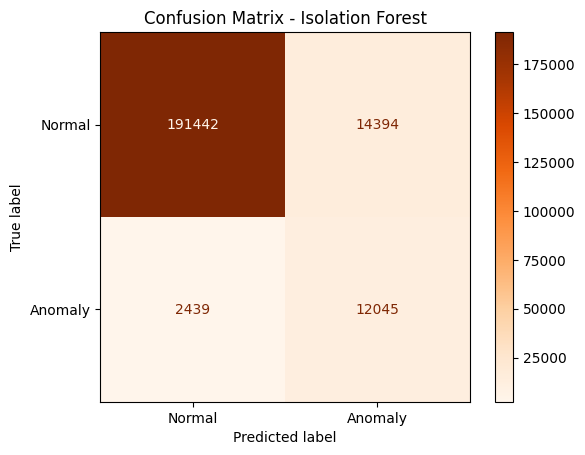

In [86]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Train the best Isolation Forest model
best_model = IsolationForest(n_estimators=80, contamination=0.12, random_state=42)
best_model.fit(df_numeric)
df_numeric.head()

# Predict anomalies using the best model
df["final_anomaly"] = best_model.predict(df_numeric)
df["final_anomaly"] = df["final_anomaly"].apply(lambda x: 1 if x == -1 else 0)  # Convert -1 to 1 (anomaly)

# Classification report
print("Classification Report:\n", classification_report(df["true_anomaly"], df["final_anomaly"]))

# Confusion matrix
conf_matrix = confusion_matrix(df["true_anomaly"], df["final_anomaly"])
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["Normal", "Anomaly"])
plt.figure(figsize=(8, 6))
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix - Isolation Forest")
plt.show()



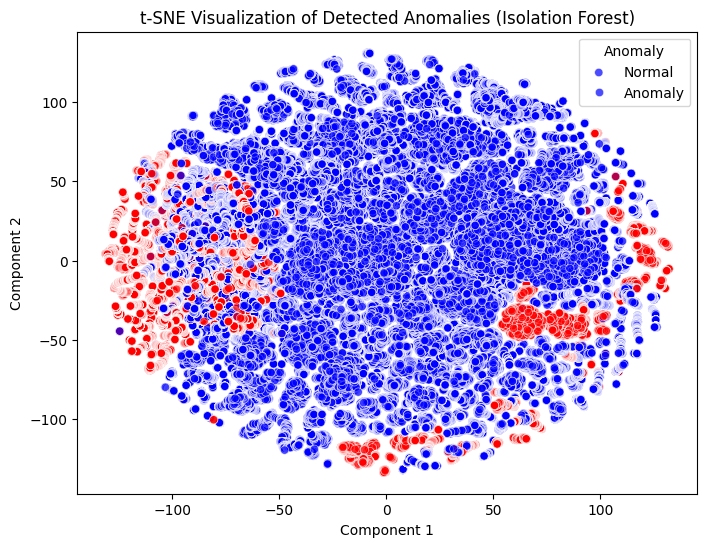

In [81]:

from sklearn.manifold import TSNE
# Apply t-SNE
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(df_numeric)

# t-SNE to DataFrame
df_tsne = pd.DataFrame(X_embedded, columns=["Component 1", "Component 2"])
df_tsne["Anomaly"] = df["final_anomaly"]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne,
    x="Component 1",
    y="Component 2",
    hue="Anomaly",
    palette={0: "blue", 1: "red"},
    alpha=0.7
)
plt.title("t-SNE Visualization of Detected Anomalies (Isolation Forest)")
plt.legend(title="Anomaly", labels=["Normal", "Anomaly"])
plt.show()


In [102]:
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

# Step 1: Map machine_status to 3 classes
df['status_3class'] = df['machine_status'].map({
    'NORMAL': 0,
    'RECOVERING': 1,
    'BROKEN': 2
})

# Step 2: Select numeric data
df_numeric = df.select_dtypes(include='number').copy()

# Step 3: Hyperparameter tuning
param_grid = {
    'covariance_type': ['diag'],
    'weight_concentration_prior': [0.1],
}

best_model = None
best_f1 = 0
results = []

for params in ParameterGrid(param_grid):
    gm = BayesianGaussianMixture(
        n_components=3,
        covariance_type=params['covariance_type'],
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=params['weight_concentration_prior'],
        init_params='kmeans',
        random_state=42
    )
    
    gm.fit(df_numeric)
    cluster_labels = gm.predict(df_numeric)

    # Align cluster labels to true labels using Hungarian matching
    conf_mat = confusion_matrix(df['status_3class'], cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-conf_mat)  # maximize matching
    label_mapping = dict(zip(col_ind, row_ind))
    aligned_preds = [label_mapping[label] for label in cluster_labels]
    
    # Calculate F1-score (macro for multiclass)
    f1 = f1_score(df['status_3class'], aligned_preds, average='macro')

    if f1 > best_f1:
        best_f1 = f1
        best_model = gm
        best_preds = aligned_preds
    
    results.append({
        'covariance_type': params['covariance_type'],
        'weight_concentration_prior': params['weight_concentration_prior'],
        'F1-score': f1
    })

# Results
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1-score', ascending=False))
print(f"\nBest F1-score (macro): {best_f1}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(df['status_3class'], best_preds, target_names=["Normal", "Recovering", "Broken"]))



  covariance_type  weight_concentration_prior  F1-score
0            diag                         0.1  0.519561

Best F1-score (macro): 0.519560887332057

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.80      0.89    205836
  Recovering       0.50      1.00      0.67     14477
      Broken       0.00      0.00      0.00         7

    accuracy                           0.81    220320
   macro avg       0.50      0.60      0.52    220320
weighted avg       0.97      0.81      0.88    220320



<Figure size 800x600 with 0 Axes>

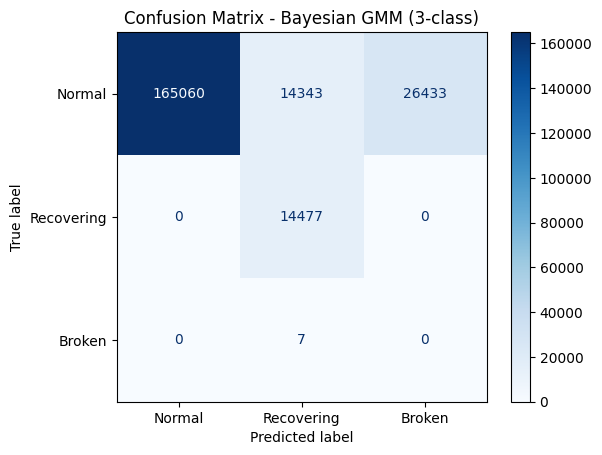

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(df['status_3class'], best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Recovering", "Broken"])
plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Bayesian GMM (3-class)")
plt.show()


## 7. Present Your Solution

### **7.1 Model Performance Comparison**
Below is a comparison of the three anomaly detection models using **Precision, Recall, and F1-score**.

The table will be updated after training and evaluating the models.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Placeholder for model performance (to be updated after training)
results = pd.DataFrame({
    "Model": ["Autoencoder", "K-Means", "Isolation Forest"],
    "Precision": [None, None, None],  # Replace with actual values after training
    "Recall": [None, None, None],     # Replace with actual values after training
    "F1-score": [None, None, None]    # Replace with actual values after training
})

# Display table

'''
print(results)

# Plot performance comparison (this will be useful after updating the values)
ax = results.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")

# Add numerical values on top of bars when the table is updated
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge")

plt.show()
'''


'\nprint(results)\n\n# Plot performance comparison (this will be useful after updating the values)\nax = results.set_index("Model").plot(kind="bar", figsize=(8, 4))\nplt.title("Model Performance Comparison")\nplt.ylabel("Score")\nplt.ylim(0, 1)\nplt.legend(loc="lower right")\n\n# Add numerical values on top of bars when the table is updated\nfor container in ax.containers:\n    ax.bar_label(container, fmt="%.2f", label_type="edge")\n\nplt.show()\n'

In [ ]:
#plotting

### **7.2 Visualization of Detected Anomalies**
This plot shows detected anomalies in sensor data by t-sne


## **7.3 Summary**
- **Best Performing Model**: *To be determined after evaluation.*
- **Observations**: *Write key findings after testing models.*
- **Challenges & Improvements**: *Note any issues such as false positives, model sensitivity, etc.*

